In [1]:
#These packages are not all necessary. I haven't removed all the unnecessary ones
from copy import deepcopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import logging
import numpy.matlib as matlib
import pandas as pd
import re
import glob
import h5py
from tqdm import tqdm
# import rasterio
# from rasterio.transform import from_origin
from datetime import datetime, timedelta
import joblib
import cartopy.io.img_tiles as cimgt

# import cartopy.crs as ccrs
# from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from subprocess import run

#From EMIT example notebook
import earthaccess
from matplotlib import pyplot as plt
import os
import warnings
import csv
from osgeo import gdal,osr
import numpy as np
import math
import rasterio as rio
import xarray as xr
# import holoviews as hv
# import hvplot.xarray
# import netCDF4 as nc
import sys
import re
from datetime import datetime, timedelta
# hv.extension('bokeh', inline=True)
warnings.simplefilter('ignore') 
# %pip install "hypercoast[all]"
import torch
import hypercoast
from hypercoast.chla import *

In [2]:
#params
wlRange=[400,700];
imgDir="PACE_AOPs_Summer2425" #PACE_OCI_L2_AOPs_GOM2025
# mapExt=[-92.5, -78.3, 41.3, 47.75]#great lakes
mapExt=[-99, -77, 23, 31] #northern Gulf of America for figure limits
matchTol=1 #time separation allowed between in-situ and satellite

#auth=earthaccess.login()

ds_path=os.getcwd()#f"/Users/josh/City College Dropbox/JOSHUA HARRINGMEYER/fPACE_hackweek/PACE_Imagery"

# ds_files=f"/Users/josh/City College Dropbox/JOSHUA HARRINGMEYER/fPACE_hackweek/PACE_Imagery/{imgDir}"
# print(ds_files)
# flist=glob.glob(os.path.join(ds_files, 'PACE_OCI.*OC_AOP.*.nc'))


print(os.getcwd())

#read in field data
fdB=pd.read_csv("/home/jovyan/2026-proj-hypoxia-zones/data/inSitu_data/noaa_GulfHypoxia_2024to2025.csv")
fdB["DATE"] = pd.to_datetime(fdB['DATE']) #pd.to_datetime(fdB["year"].astype(str) + fdB["DOY"].astype(str).str.zfill(3),format="%Y%j")
imDates = pd.concat([fdB["DATE"] - pd.Timedelta(days=1),fdB["DATE"],fdB["DATE"] + pd.Timedelta(days=1)]).sort_values().reset_index(drop=True).unique() #get unique PACE days to query

fdB["site_id"]=fdB["CRUISE"].astype(str)+'_'+fdB["STATION"].astype(str) #create a unique identifier for the NOAA Gulf Hypoxia stations.

/home/jovyan/2026-proj-hypoxia-zones/contributor_folders/Harringmeyer


In [3]:
#Create algorithm functions (these return total suspended sediment using red-band brightness).
def nechad665(Rrs_665):
    tsm = (355.85 * math.pi * Rrs_665) / (1 - math.pi * Rrs_665 / 17.28e-2)+1.84 #2010 numbers
    return tsm
    
def nechad16_715(Rrs_715):
    turb = (560.06 * math.pi * Rrs_715) / (1 - math.pi * Rrs_715 / 19.04e-2)
    return turb

def nechad16_665(Rrs_665):
    turb = (602.49 * math.pi * Rrs_665) / (1 - math.pi * Rrs_665 / 0.2385)
    return turb


def pixelStn(sp3x3_full):
    ## function for flattening and returning a median spectrum, number of "good" pixels, and coefficient of variation for a set of matchp pixels (usually 3x3)
    VisWL=((sp3x3_full['wavelength']>=400) &  (sp3x3_full['wavelength']<650))
    mask_pxl=(sp3x3_full.where(VisWL)<0).any(dim='wavelength')
    sp3x3=sp3x3_full.where(~mask_pxl)
    numGood=(~mask_pxl['Rrs'].values).sum()
    
    m0=sp3x3.mean(dim=('number_of_lines', 'pixels_per_line'),skipna=True)        
    sd0=sp3x3.std(dim=('number_of_lines', 'pixels_per_line'),skipna=True) 
    cv1=sd0['Rrs'].values/m0['Rrs'].values

    median_spectrum_wrap = sp3x3.median(dim=('number_of_lines', 'pixels_per_line'),skipna=True)
    median_spectrum=median_spectrum_wrap['Rrs'].values
    
    return median_spectrum, numGood, np.nanmean(cv1)
    


In [4]:
#create subdirectories (if they don't exist) for making summary maps the loop 
mDirs=["SPM_Nechad2010_Rrs665"]#,"PACE_DOC_RF","PACE_ag300_RF","PACE_S275295_RF","PACE_DOC_xgb","PACE_ag300_xgb","PACE_S275295_xgb","PACE_DOC_SVM","PACE_ag300_SVM","PACE_S275295_SVM"]
for m1 in mDirs:
    os.makedirs(ds_path+"/"+m1,exist_ok=True)

In [5]:
print(imDates[0].strftime("%Y-%m-%d"))
print((mapExt[0],mapExt[2],mapExt[1],mapExt[3]))

2024-06-03
(-99, 23, -77, 31)


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

PACE_OCI.20240603T175658.L2.OC_AOP.V3_1.nc
<File-like object S3FileSystem, ob-cumulus-prod-public/PACE_OCI.20240603T175658.L2.OC_AOP.V3_1.nc>
<xarray.Dataset> Size: 3GB
Dimensions:        (number_of_bands: 286, number_of_reflective_bands: 286,
                    wavelength_3d: 172, number_of_lines: 1710,
                    pixels_per_line: 1272)
Coordinates:
  * wavelength_3d  (wavelength_3d) float64 1kB 346.0 348.0 351.0 ... 717.0 719.0
    longitude      (number_of_lines, pixels_per_line) float32 9MB dask.array<chunksize=(256, 1272), meta=np.ndarray>
    latitude       (number_of_lines, pixels_per_line) float32 9MB dask.array<chunksize=(256, 1272), meta=np.ndarray>
Dimensions without coordinates: number_of_bands, number_of_reflective_bands,
                                number_of_lines, pixels_per_line
Data variables: (12/30)
    wavelength     (number_of_bands) float64 2kB dask.array<chunksize=(32,), meta=np.ndarray>
    vcal_gain      (number_of_reflective_bands) float32 1kB da

FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/2026-proj-hypoxia-zones/contributor_folders/Harringmeyer/PACE_Nechad2010_Rrs665/N10_PACE_OCI.20240603T175658.L2.OC_AOP.V3_1.nc.png'

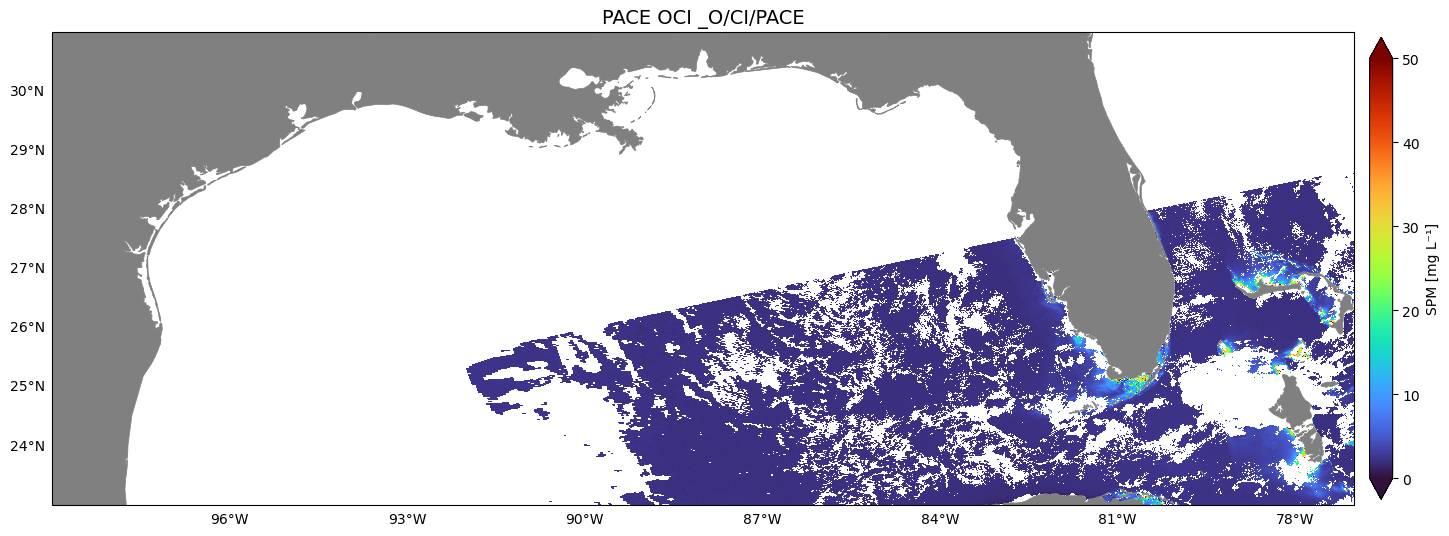

In [7]:
match_Spectra = pd.DataFrame()
zz=0
auth = earthaccess.login()

for dd in imDates:
    # img_ID = re.search(r"PACE_OCI.(.*?).L2", fp).group(1)
    # print(img_ID)
    # iDay = pd.to_datetime(f"{img_ID[0:4]}{img_ID[4:6]}{img_ID[6:8]}", format="%Y%m%d")
    iDay = dd
    
    bbox = (mapExt[0],mapExt[2],mapExt[1],mapExt[3]) #assign bounding box from "map extent" at the top of the notebook
    # bbox = (-98.0, 27.0, -96.0, 31.0)
    strDate=dd.strftime("%Y-%m-%d")
    results = earthaccess.search_data(short_name = "PACE_OCI_L2_AOP",temporal = (strDate,strDate),bounding_box = bbox)
    fileset = earthaccess.open(results);
    
    wlSave=0
    for ff in fileset:
        img_ID = os.path.basename(ff.path)
        print(img_ID)

        print(ff)
        datatree = xr.open_datatree(fileset[0], decode_timedelta=False, chunks={}) 
        ds = xr.merge(datatree.to_dict().values())
        ds = ds.set_coords(("longitude", "latitude"))        
        print(ds)
        
        # print(ds0)
        # ds = ds0['Rrs'] 
        wvl = ds['wavelength'].values
        # # wvl = xr.open_dataset(fp,group='sensor_band_parameters')['wavelength_3d'].values
        if wlSave==0:
            np.savetxt("PACE_wl.csv", wvl, delimiter=",")
            wlSave+=1
            
        # navD = xr.open_dataset(fp, group="navigation_data")
        # navD = navD.set_coords(("longitude", "latitude"))
        # ds_geo = xr.merge((ds, navD.coords))
        # ds_geo = ds_geo.assign_coords(wavelength=("wavelength_3d", wvl))
        # ds_geo = ds_geo.swap_dims({"wavelength_3d": "wavelength"})
        # rrs = ds_geo["Rrs"].sel(wavelength = 665,method='nearest')
        # rrs=ds["Rrs"]
        
        n665=nechad665(ds['Rrs'].sel(wavelength_3d=665,method='nearest'))
        
        fig = plt.figure(figsize=(20, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.set_extent(mapExt)  
        # tiler = cimgt.QuadtreeTiles()
        # tiler = cimgt.GoogleTiles(desired_tile_form='RGB', style='satellite')# ESRI World Imagery
        # ax.add_image(tiler, 8)         # Zoom level (8–12 works well)
        
        # ax.coastlines()
        gl=ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
        gl.xlines = False
        gl.ylines = False
        ax.add_feature(cfeature.STATES, linewidth=0.5,edgecolor="black",color="gray")   # ✅ State boundaries
        plot = n665.plot(x="longitude", y="latitude", cmap="turbo", ax=ax,vmin=0,vmax=50,cbar_kwargs={
            "label": "SPM [mg L⁻¹]", #Remote Sensing Reflectance (sr⁻¹)",
            "shrink": 0.6,  # Shrink colorbar to match height of map
            "pad": 0.01     })# Space between plot and colorbar
        
        dayMatch=(fdB["DATE"] - iDay).abs().dt.days <= matchTol    
        
        ax.set_title(f"PACE OCI {img_ID[4:6]}/{img_ID[6:8]}/{img_ID[0:4]}", fontsize=14)
        plt.savefig(ds_path+f"/PACE_Nechad2010_Rrs665/N10_{img_ID}.png", dpi=300, bbox_inches='tight')
        plt.clf()
        
        
        # lat_min, lat_max = float(ds_geo.latitude.min()), float(ds_geo.latitude.max())
        # lon_min, lon_max = float(ds_geo.longitude.min()), float(ds_geo.longitude.max())
        lat_min, lat_max = float(ds['latitude'].values.min()), float(ds['latitude'].values.max())
        lon_min, lon_max = float(ds['longitude'].values.min()), float(ds['longitude'].values.max())
        
        insideImg = ((fdB["latitude"].between(lat_min, lat_max)) & (fdB["longitude"].between(lon_min, lon_max)))    
        fdBmatch_N=fdB.loc[dayMatch & insideImg,]
        
        fdBmatch_N=fdB.loc[dayMatch & insideImg,"site_id"]
        fdBmatch=fdB.loc[dayMatch & insideImg,]
        wn=['PRrs'+str(int(ll)) for ll in ds['wavelength'].round()]
        wlNum=[ll for ll in ds['wavelength']]
        for index,row in fdBmatch.iterrows():
            #match the location to the lat/lon and get a 3x3 box
            min_idx = ((ds['latitude'] - row['latitude'])**2 + (ds['longitude'] - row['longitude'])**2).argmin()
            iline, ipixel = np.unravel_index(min_idx.item(),(ds.dims['number_of_lines'], ds.dims['pixels_per_line']))        
            match_3x3 = ds.isel(number_of_lines=slice(max(iline-1, 0), iline+2),pixels_per_line=slice(max(ipixel-1, 0), ipixel+2))
            match_3x3['Rrs'] = match_3x3['Rrs'].where(match_3x3['Rrs'] != -9999)
            
            median_spectrum, ng, CVbox = pixelStn(match_3x3)
            matchPoint = ds.where(distance == distance.min(), drop=True)
            MP_values=matchPoint['Rrs'].values
            MP_values[MP_values==-9999]=np.nan
            MP_df=pd.DataFrame(columns=wn)
            # MP_df.loc[len(MP_df)]=MP_values.ravel()
            MP_df.loc[len(MP_df)]=median_spectrum.ravel()
            ISdf=row.to_frame().T.reset_index(drop=True)
            ISdf['imageName']=img_ID[0:15]
            ISdf['nGoodPixels']=ng
            ISdf['matchSpec_CV']=CVbox
            ISdf['time_sep_days']=abs(row["DATE"] - iDay).days
            MPfull=pd.concat([ISdf, MP_df.reset_index(drop=True)], axis=1)
            match_Spectra = match_Spectra._append(MPfull,ignore_index=True)
            
    

match_Spectra.to_csv(ds_path+f"/PACE_IS_Matchup_spectra{imgDir}.csv", index=False)

In [14]:
dd0=pd.read_csv(ds_path+f"/PACE_IS_Matchup_spectra{imgDir}.csv")
dd0['pad']='_'
dd0['unID']=dd0[['site_id','pad','imageName']].astype(str).sum(axis=1)


# print(dd0['unID'][0])
ss=0
for index, row in dd0.iterrows():
    # print(row[['PRrs490','PRrs555','PRrs665']])
    # print(not(pd.isna(row[['PRrs490','PRrs555','PRrs665']]).all()))
    if not(pd.isna(row[['PRrs490','PRrs555','PRrs665']]).all()):
        if ss==0 :
            pm = row.to_frame().T
        else:
            if ss==1:
                if not((pm['unID']==row['unID']).any()):
                   pm=pd.concat([pm,row.to_frame().T],axis=0,ignore_index=True)
            else:
                if not(pm['unID'].str.contains(row['unID']).any()):
                    pm=pd.concat([pm,row.to_frame().T],axis=0,ignore_index=True)
        ss+=1

# print(pm['PRrs555'])
pm = pm.sort_values(
    by=['CRUISE', 'STATION','unID'],ascending=[True, True,True]).reset_index(drop=True)
pm.to_csv("Unique_PACE_matchups_NOAA_Hypoxia_2024_2025.csv", index=False)

0      0.001782
1      0.001699
2      0.001778
3      0.001832
4      0.002598
         ...   
848     0.00206
849    0.001945
850    0.001856
851    0.002812
852    0.002262
Name: PRrs555, Length: 853, dtype: object


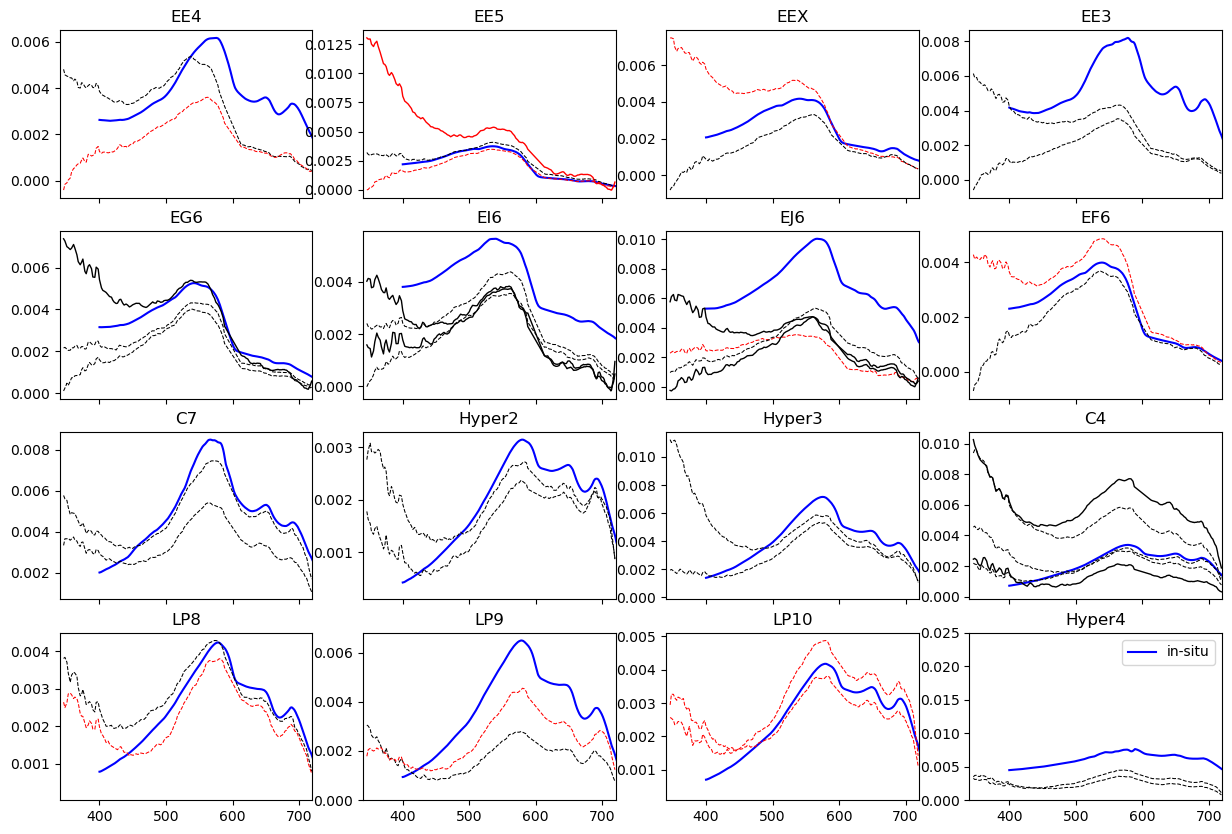

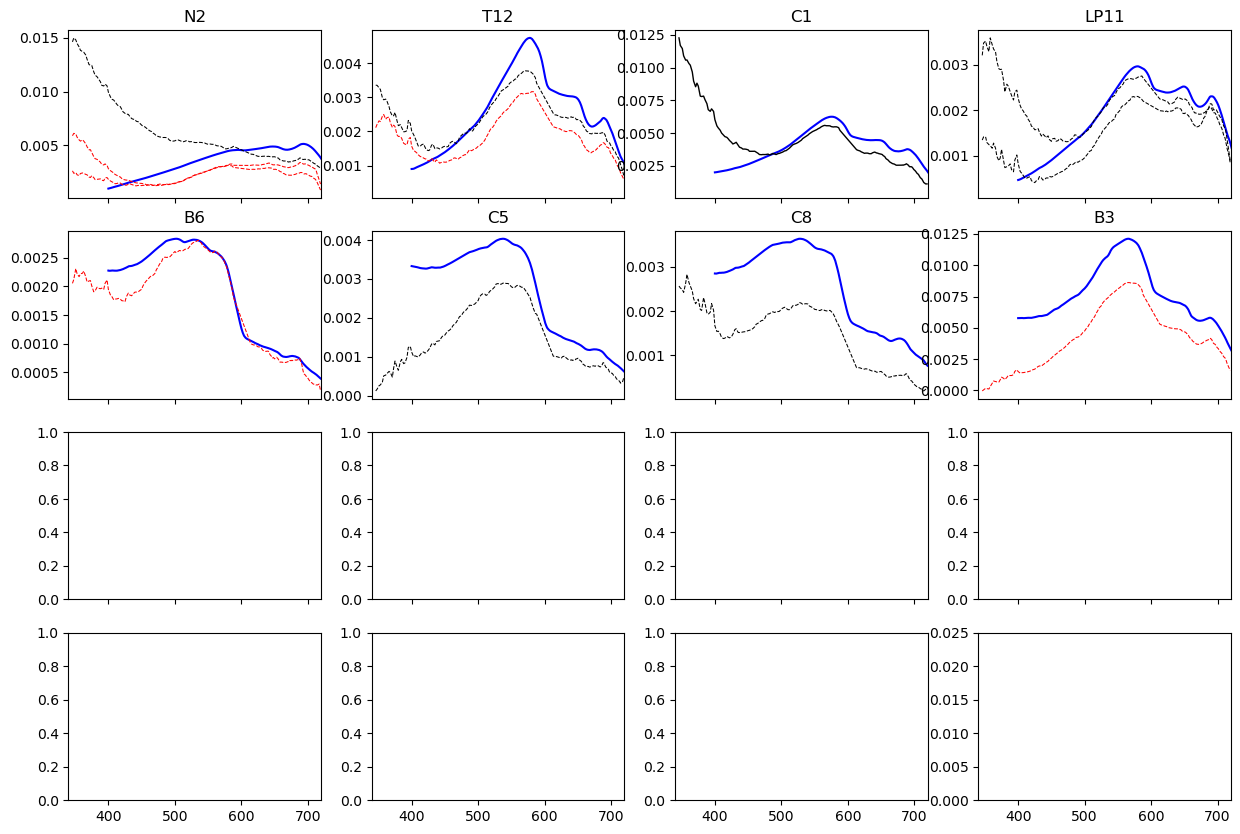

In [ ]:
# dd= dd0[dd0['PRrs500'].notna() & dd0['Rrs500'].notna()]
dd = dd0[dd0['PRrs500'].notna() & (dd0['PRrs500'] != '') & dd0['Rrs500'].notna()  & (dd0['Rrs500']  != '')]
# dd.to_csv(ds_path+f"/actual_matchups.csv", index=False)
mNames=pd.unique(dd['site_id']).tolist()

for m in range(1,len(mNames)//16+2):
    block = [i + 16*(m-1) for i in range(16)]
    # block = [i for i in block if i < len(mNames)]
    stnSubset = [mNames[i] for i in block if i < len(mNames)]
    fig, axes = plt.subplots(nrows=4,ncols=4, figsize=(15,10), sharex=True)
    for i in range(len(stnSubset)):
        ll=0
        ss=stnSubset[i]
        dd1=dd.loc[dd['site_id']==ss,:]
        for index,row in dd1.iterrows(): 
            qcol = 'red' if ((row['matchSpec_CV']>=0.2) or (row['nGoodPixels']<5)) else 'black'
            line_lab = 'PACE Qual Flag' if ((row['matchSpec_CV']>=0.2) or (row['nGoodPixels']<5)) else 'PACE'
            if ll==0:
                axes[i//4,(i%4)-1].plot(list(range(380, 901)),row.loc['Rrs380':'Rrs900'].values,color='blue',label="in-situ")
                ll+=1
            if row['time_sep_days']<1:
                axes[i//4,(i%4)-1].plot(wlNum,row.loc['PRrs346':'PRrs719'].values,color=qcol,linestyle='-', linewidth=1,label="PACE")
            else:
                axes[i//4,(i%4)-1].plot(wlNum,row.loc['PRrs346':'PRrs719'].values,color=qcol,linestyle='--', linewidth=0.75)
            axes[i//4,(i%4)-1].set_title(f"{row['site_id']}")
            plt.xlim([340, 720])
            plt.ylim([0,0.025])
            if m==1 and i==(len(stnSubset)-1):
                plt.legend()
            
    plt.ylim([0,0.025])
                        
    plt.savefig(ds_path+f"/PACE_{imgDir}_Field_Matchup_Rrs{m}.png")

#plt.tight_layout()
plt.show()

# for i, row in df.iterrows():
#     plt.plot(x, row.values, label=f"Row {i}")

# plt.xlabel("Wavelength (nm)")
# plt.ylabel("Reflectance")
# plt.legend()
# plt.show()

In [7]:
PACE_match.shape()

TypeError: 'tuple' object is not callable